In [42]:
# AUDIO MANIPULATION
import sounddevice as sd
import soundfile as sf

# PLAY recording  and Analyze GAIN
from _ms_pod_global_functions import wav_play ,wav_analyze_gain
# Analyze FREQ distribution
from _ms_pod_global_functions import wav_freq_dist_pie_chart, wav_freq_dist_plot,wav_plot_spectrogram

# MIXED plots #PLOT amplitud, lufs, spectogram 
from _ms_pod_global_functions import  wav_plot_3 ,wav_audio_ana_6

# COMPARE DIRECTORY  input for wav files IN ONE FOLDER
from _ms_pod_global_functions import direc_wav_compare_spct

In [43]:
file_path = "/Users/yerik/Downloads/downloads_CLIENTS/_au_0_.wav"
_path = file_path 

# fns

# PODCAST ANALYSIS - 0 EDA -- 1 VOL & -- 2 FREQ
# 3 # PODCAST EDITING  - (a) HP (b) NR (c) NG

In [44]:
# Global 


# AUDIO MANIPULATION
import sounddevice as sd
import soundfile as sf

# PLAY recording  and Analyze GAIN
from _ms_pod_global_functions import wav_play ,wav_analyze_gain
# Analyze FREQ distribution
from _ms_pod_global_functions import wav_freq_dist_pie_chart, wav_freq_dist_plot,wav_plot_spectrogram

# MIXED plots #PLOT amplitud, lufs, spectogram 
from _ms_pod_global_functions import  wav_plot_3 ,wav_audio_ana_6

# COMPARE DIRECTORY  input for wav files IN ONE FOLDER
from _ms_pod_global_functions import direc_wav_compare_spct

### <<< 0 >>> Audio MANIPULATION

In [45]:
# Query and print all audio devices
sd.query_devices()

# # PLAY AUDIO without being saved
# sd.play(audio_data, RATE, device=2 )
# sd.wait()

# ATTN -> miss fn to get wav 1 channel from any format and client info/tags get info of lenght etc 
# RAW AUDIO input 
direc_wav = "/Users/yerik/Downloads/downloads_CLIENTS/"

#file_path = f"{direc_wav}/_0_vr_raw_.wav" # RAW
file_path =  _path #f"{direc_wav}/_0_voc_vr.wav"  # w DEMCUS 

#wav_play(file_path)

###  <<< 1 >>> VOLUME ANALYSIS:

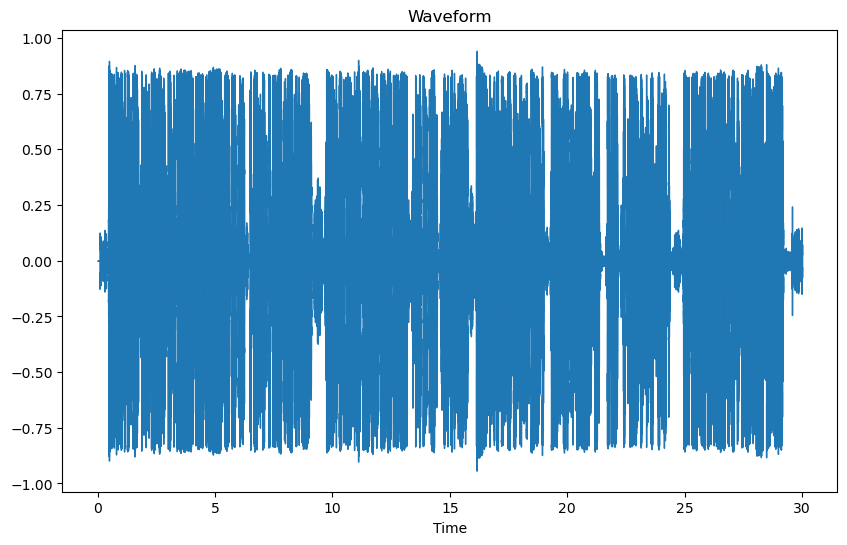

Peak Level (linear scale): 0.943
RMS Level (linear scale): 0.203
RMS Level (dBFS): -13.84 dB

Frequency Band Power (dB):
Super Low (< 50Hz): 2.29 dB
Low (50Hz - 400Hz): 57.36 dB
Mid (400Hz - 4kHz): 41.11 dB
High (> 4kHz): 6.26 dB

Interpretation:
- Your recording level is within the typical range for spoken content.
signfc power in low frequencies, which add unnecessary rumble or noise. Consider using a high-pass filter.


In [46]:
wav_analyze_gain(file_path) # CHECK AMPLITUDE FOR GAIN PURPOSES - ### low GAIN  ### CLIPPING WARNING

###  <<< 2 >>>  FREQUENCY ANALYSIS:

##### 0 to 50 Hz: Purpose: This very low-end range provides the rumble and sub-bass content. --->  < 5% 
##### 50 to 400 Hz: freq of male voices mostly reside here, giving the voice body/fullness.  --->  ~ 40%
##### 400 to 4000 Hz: freq w harmonic content, presence/clarity. vital for intelligibility.  --->  ~ 55%

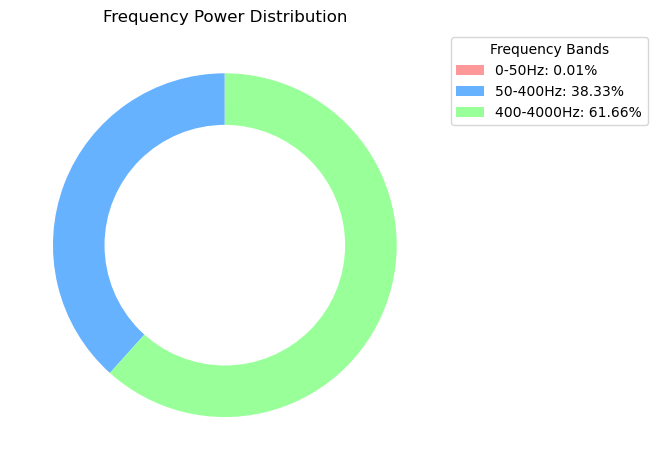

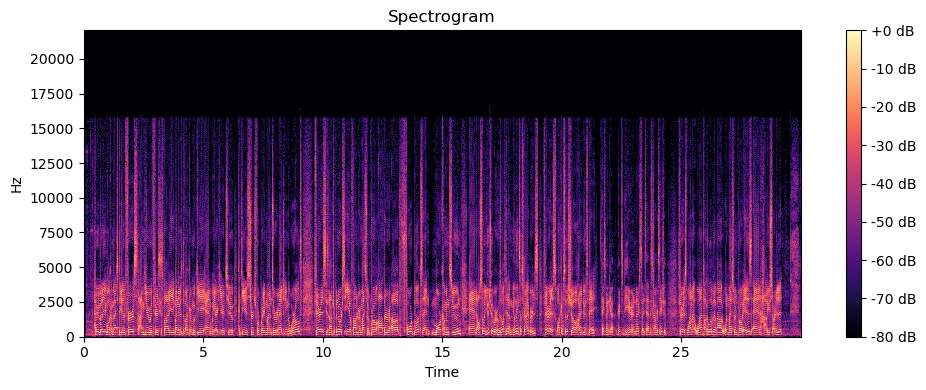

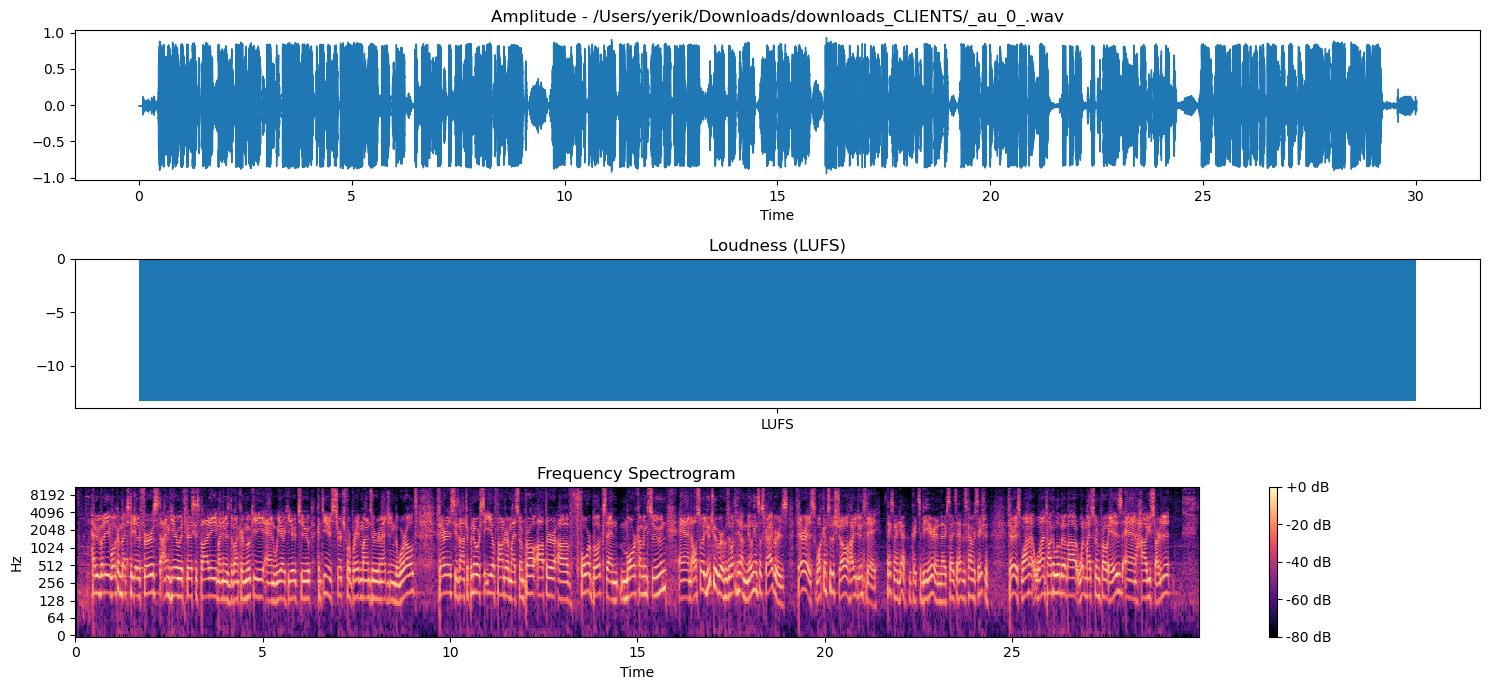

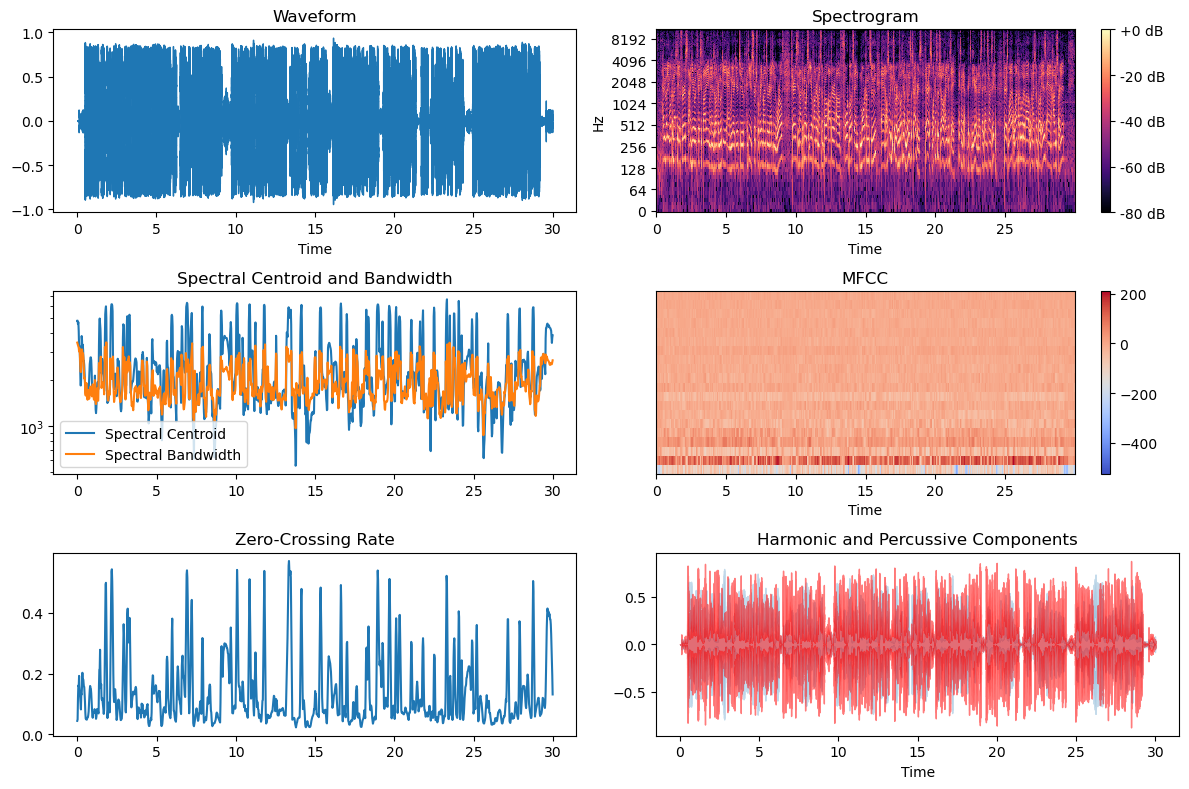

In [47]:
wav_freq_dist_pie_chart(file_path) # CHECK FREQ DISTRIUTION
#wav_freq_dist_plot(file_path) # check freq distributions PLOTS
wav_plot_spectrogram(file_path)

# FURTHER ANALYSIS--------- PLOTS

wav_plot_3(file_path)
wav_audio_ana_6(file_path)

# AFTER MODIFyING COMPARE FOLDER ----------- ALL wavs in FOLDER PLOTS
#direc_wav_compare_spct(direc_wav)

# <<< 3 4 5 >>> AUDIO EDITING

In [48]:
# HP functions
from _ms_pod_editing_functions import wav_hp_mod_1
# NR functions
from _ms_pod_editing_functions import wav_nr_mod_1 ,wav_nr_mod_2
# NOISE GATE
from _ms_pod_editing_functions import wav_ng_mod_1, wav_ng_mod_2_pad
# NORMALIZATION 

from _ms_pod_editing_functions import wav_norm_first, wav_comp_norm_lufs

#from _ms_pod_editing_functions import

print(f' EDITING functions working currently in ::: \n*\n*\n*\n*{file_path}\n*\n*\n*\n*')

 EDITING functions working currently in ::: 
*
*
*
*/Users/yerik/Downloads/downloads_CLIENTS/_au_0_.wav
*
*
*
*


### ::: 3a ::: High Pass

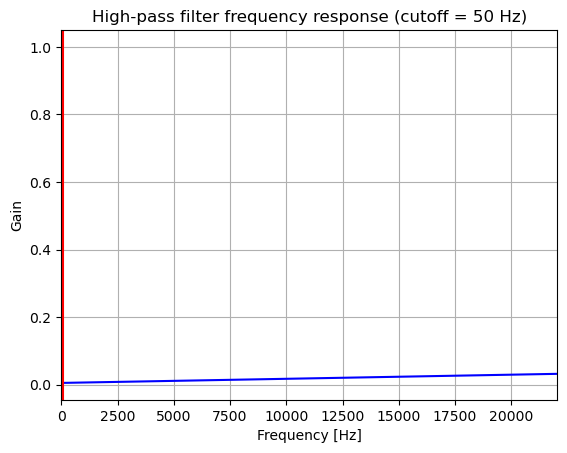

In [49]:
# Usage example
y_hpf, sr = wav_hp_mod_1(file_path, cutoff_frequency=50, order=6)

# Save the high-pass filtered audio
out_file_path_hp_m1 = f"{direc_wav}/_1_vr_raw_iii_HP50"
# Write
sf.write(f'{out_file_path_hp_m1}.wav', y_hpf, sr)

### ::: 3b ::: Noise Reduction (NR) mod_1

In [50]:
# Usage
# Adjust 'audio_path', 'noise_reduction_level', and 'sensitivity' as needed
noise_reduced_output_1 = wav_nr_mod_1(f'{out_file_path_hp_m1}.wav', 0.9, 0.9)

# Save the high-pass filtered audio
out_file_path_nr_m1 = f"{direc_wav}/_2_vr_HP50_iii_NR"
# Write
sf.write(f'{out_file_path_nr_m1}.wav', noise_reduced_output_1, sr)
# Write to a file


##### Noise Reduction (NR) mod_2

In [51]:
# Adjust 'audio_file_path', 'noise_reduction_factor', 'frame_length', and hop_length' as needed
noise_reduced_output_2, sample_rate = wav_nr_mod_2(f'{out_file_path_nr_m1}.wav', 2.8)


# Save the high-pass filtered audio
out_file_path_nr_m2 = f"{direc_wav}/_2b_vr_NR_iii_NR_mod_2"
# Write
sf.write(f'{out_file_path_nr_m2}.wav', noise_reduced_output_2, sample_rate)
# Write to a file


### ::: 3c ::: NOISE GATE - NOT PADDiNG - for low volumes (-80,-60) -- mod_1

In [52]:
#So, 0.01 seconds is equivalent to 10 milliseconds. , attack ~ .01 , release~ .3 (300)

input_file = f'{out_file_path_nr_m2}.wav'

out_file_path_ng_m1 = f"{direc_wav}/_3_vr_NR_mod_2_iii_NG-70_ARdot0105"

# SAVE and EXPORT inside the fn 
wav_ng_mod_1(input_file, f'{out_file_path_ng_m1}.wav', gate_threshold=-63.0, attack=0.29, release=.05)

# <<< 4 >>>   NORMALIZATION and Second NOiSE GATE

#### ::: 4a ::: first Normalization - PEAK NORMALIZATION

In [53]:


# Assume the normalize_audio function is already defined as provided earlier
norm_type = 'peak'  # or 'rms'
# Using the function
input_file_path = f'{out_file_path_ng_m1}.wav' # Replace with your input file path
out_file_path_norm_1 = f"{direc_wav}/_4_vr_NORM_{norm_type}"#{my_level}"

norm_1_audio,sample_rate = wav_norm_first(input_file_path, normalization_type=norm_type, target_level=-0.9)

# Export the normalized audio to a file
sf.write(f"{out_file_path_norm_1}.wav",norm_1_audio, sample_rate)


#### ::: 4b ::: second NG

In [54]:


input_file_path = f'{out_file_path_norm_1}.wav' # Replace with your input file path

out_file_path_norm_ng = f"{direc_wav}/_4b_vr_NORM_{norm_type}_to_NG"#{my_level}"


wav_ng_mod_2_pad(input_file_path, f"{out_file_path_norm_ng}.wav", gate_threshold=-93.0, attack=0.19, release=0.02)


# <<< 5 >>> COMPRESSION and LAST NORMALIZATIONzz

In [55]:
# Usage
input_file = f"{out_file_path_norm_ng}.wav"#{my_level}"

out_comp_norm_lufs = f"{direc_wav}/_5_vr_LUFS_comp_and_norm"

wav_comp_norm_lufs(input_file, f"{out_comp_norm_lufs}.wav", threshold=-0.95, ratio=2.0, attack=0.29, release=0.02, target_lufs=-26.0)


# END

# further research - DE- ESSER and MULTI BADN COMOPRESSOR 

In [56]:
import librosa
import numpy as np
from scipy.signal import butter, lfilter

# Function to apply high-pass filter
def high_pass_filter(audio, sr, cutoff=50):
    nyquist = 0.5 * sr
    norm_cutoff = cutoff / nyquist
    b, a = butter(1, norm_cutoff, btype='high', analog=False)
    filtered_audio = lfilter(b, a, audio)
    return filtered_audio

# Load audio
audio_path = f"{out_comp_norm_lufs}.wav"  # Replace with your audio path
audio, sr = librosa.load(audio_path, sr=None)

# Apply high-pass filter
filtered_audio = high_pass_filter(audio, sr, cutoff=50)

In [57]:
import librosa.display
import matplotlib.pyplot as plt
from scipy.signal import iirfilter, sosfilt

# Function to apply EQ (reduce 50Hz-400Hz)
def apply_eq(audio, sr, low_gain=-8.0):
    eq_band = [50, 400]
    sos = iirfilter(
        N=4,
        Wn=[x / (0.5 * sr) for x in eq_band],
        btype="band",
        ftype="butter",
        output="sos",
    )
    eq_audio = sosfilt(sos, audio)
    return audio + eq_audio * low_gain

eq_audio = apply_eq(filtered_audio, sr)


In [58]:
import pyloudnorm as pyln
import soundfile as sf
import numpy as np
import os

# Example function to normalize loudness
def normalize_loudness(audio, sr, target_loudness=-14.0):
    # Create a Meter object
    meter = pyln.Meter(sr)  # Sampling rate
    loudness = meter.integrated_loudness(audio)  # Measure loudness

    # Normalize the audio to the target loudness
    normalized_audio = pyln.normalize.loudness(audio, loudness, target_loudness)
    return normalized_audio

# Assuming `eq_audio` is the audio after applying EQ
target_loudness = -14.0  # Typical loudness target in LUFS
normalized_audio = normalize_loudness(eq_audio, sr, target_loudness)

# Save normalized audio
output_file = f"{direc_wav}/_000_RESULTS/processed_audio.wav"
os.makedirs(os.path.dirname(output_file), exist_ok=True)  # Ensure the directory exists
sf.write(output_file, normalized_audio, sr)

print(f"Normalized audio saved at: {output_file}")


Normalized audio saved at: /Users/yerik/Downloads/downloads_CLIENTS//_000_RESULTS/processed_audio.wav


/Users/yerik/_envs/_2ms_envs/ms_env/lib/python3.8/site-packages/pyloudnorm/normalize.py:62: UserWarning: Possible clipped samples in output.
  warnings.warn("Possible clipped samples in output.")


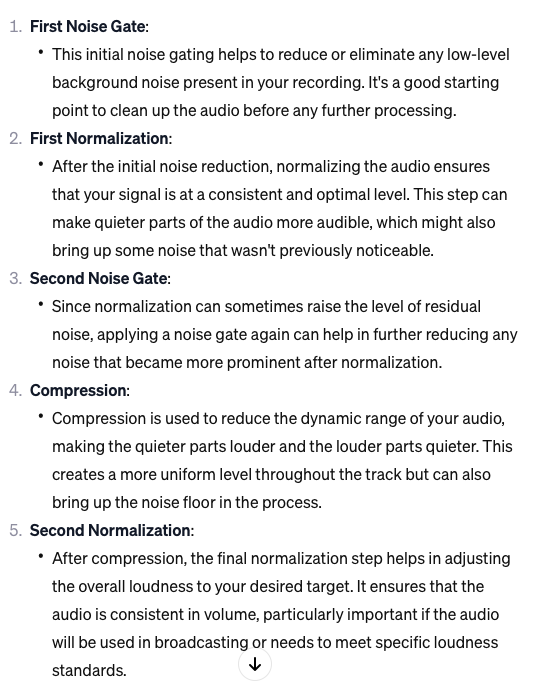

Both steps are crucial for professional audio processing, especially for podcasts and broadcast content. Compression ensures consistent audibility within the track, and LUFS normalization ensures that the overall loudness meets the standards of the intended platform, providing a uniform listening experience. This combination is key to achieving high-quality, platform-compliant audio content.

Adjust the Compression Threshold: Lowering the compression threshold means that more parts of the audio will be subjected to compression

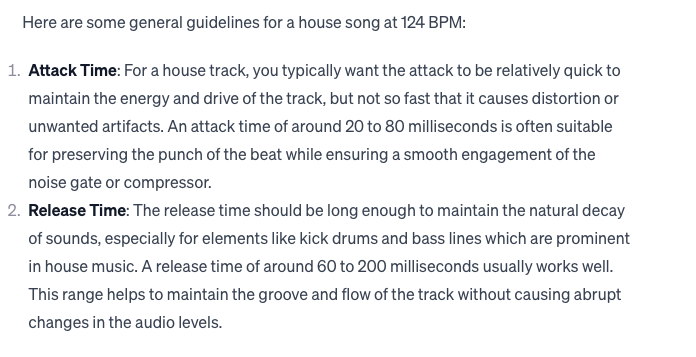

## LAST TOUCHES if clipping still 

In [59]:
import os
import numpy as np
import librosa
import soundfile as sf
from scipy.signal import butter, lfilter
import pyloudnorm as pyln

# Define directory and input/output paths
input_file = f"{direc_wav}/_000_RESULTS/processed_audio.wav"
output_file = f"{direc_wav}/_000_RESULTS/final_processed_audio.wav"

# Ensure the output directory exists
os.makedirs(os.path.dirname(output_file), exist_ok=True)

# Step 1: Load the audio file
audio, sr = librosa.load(input_file, sr=None)

# Step 2: Reduce gain to prevent clipping
def reduce_gain(audio, reduction_db=3.0):
    reduction_factor = 10 ** (-reduction_db / 20)
    return audio * reduction_factor

audio = reduce_gain(audio, reduction_db=1.0)  # Reduce gain by 1 dB

# Step 3: Apply limiter to prevent peaks from exceeding the threshold
def apply_limiter(audio, threshold=0.95):
    return np.clip(audio, -threshold, threshold)

audio = apply_limiter(audio, threshold=0.95)

# Step 4: Apply soft clipping for smooth peak handling
def soft_clipper(audio, threshold=0.95):
    return np.tanh(audio / threshold) * threshold

audio = soft_clipper(audio, threshold=0.95)

# Step 5: Apply a low-pass filter to smooth high-frequency artifacts
def low_pass_filter(audio, sr, cutoff=16000):
    nyquist = 0.5 * sr
    norm_cutoff = cutoff / nyquist
    b, a = butter(4, norm_cutoff, btype='low', analog=False)
    return lfilter(b, a, audio)

audio = low_pass_filter(audio, sr, cutoff=16000)

# # Step 6: Re-normalize the audio to a target loudness level
# def normalize_loudness(audio, sr, target_loudness=-14.0):
#     meter = pyln.Meter(sr)  # Create a loudness meter
#     loudness = meter.integrated_loudness(audio)  # Measure current loudness
#     normalized_audio = pyln.normalize.loudness(audio, loudness, target_loudness)
#     return normalized_audio

# audio = normalize_loudness(audio, sr, target_loudness=-14.0)

# Step 7: Save the processed audio
sf.write(output_file, audio, sr)
print(f"Processed audio saved at: {output_file}")


Processed audio saved at: /Users/yerik/Downloads/downloads_CLIENTS//_000_RESULTS/final_processed_audio.wav


# END